#### Principal Comonent Analysis (PCA)

Correlated Data in Nature

Correlation:  0.8604149377143469


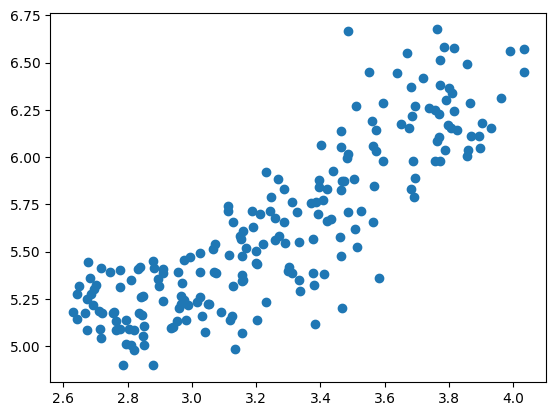

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import pearsonr

grains = pd.read_csv("./datasets/seeds-width-vs-length.csv", header=None)

width = grains.iloc[:, 0].values
length = grains.iloc[:, 1].values

correlation, pvalue = pearsonr(width, length)

print("Correlation: ", correlation)

plt.scatter(width, length)
plt.show()

Decorrelating the grain measurements with PCA

Correlation:  -5.359753439682091e-15


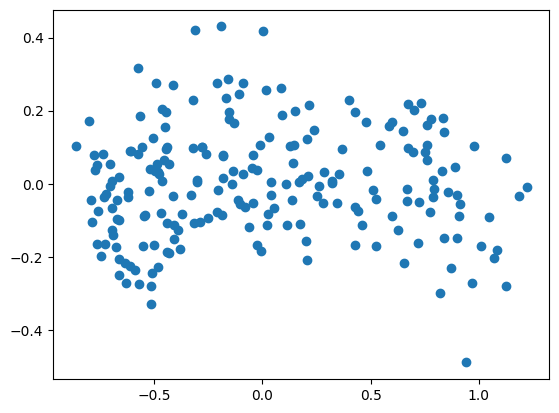

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from scipy.stats import pearsonr

samples = pd.read_csv("./datasets/seeds-width-vs-length.csv", header=None).values

model = PCA()
pca_features = model.fit_transform(samples)

xs = pca_features[:, 0]
ys = pca_features[:, 1]

correlation, pvalue = pearsonr(xs, ys)

print("Correlation: ", correlation)

plt.scatter(xs, ys)
plt.show()

The first principal component

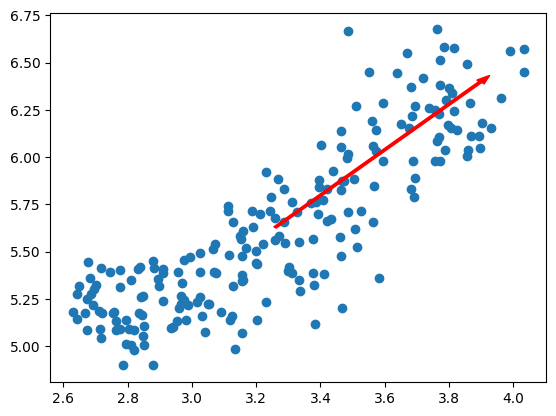

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA

grains = pd.read_csv("./datasets/seeds-width-vs-length.csv", header=None).values

model = PCA()
model.fit_transform(grains)

mean = model.mean_
first_pc = model.components_[:, 0] # first component - component with the most varience

plt.scatter(grains[:, 0], grains[:, 1])
plt.arrow(mean[0], mean[1], first_pc[0], first_pc[1], color="red", width=0.01)

plt.show()

Varience of PCA features

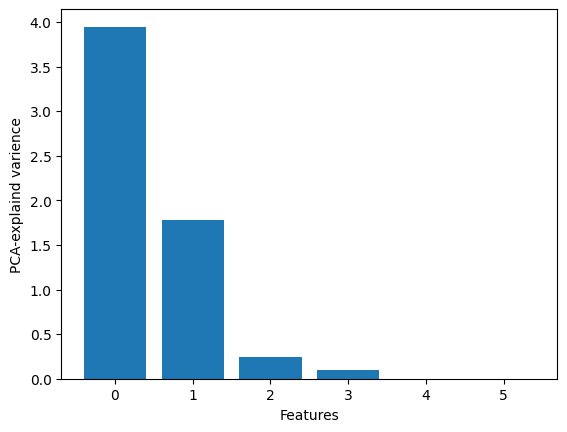

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline

samples = pd.read_csv("./datasets/fish.csv", header=None).iloc[:, 1:].values

scaler = StandardScaler()
model = PCA()

pipeline = make_pipeline(scaler, model)
pipeline.fit(samples)

# plot the explained varience
features = range(model.n_components_)

plt.bar(features, model.explained_variance_)
plt.xlabel("Features")
plt.ylabel("PCA-explaind varience")
plt.xticks(features)
plt.show()

Dimension reduction of the fish measurements

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

samples = pd.read_csv("./datasets/fish.csv", header=None).iloc[:, 1:].values

scaled_samples = StandardScaler().fit_transform(samples)
pca = PCA(n_components=2)

pca_features = pca.fit_transform(scaled_samples)

print(pca_features.shape)

(85, 2)


Reduce word frequency data using TruncatedSVD

In [7]:
import numpy as np
from scipy.sparse import csr_matrix
from sklearn.decomposition import TruncatedSVD

X =  np.array([
    [3, 0, 0, 2, 0],
    [0, 5, 1, 0, 0],
    [1, 0, 0, 0, 4],
    [0, 2, 3, 0, 1]
])

X_sparse = csr_matrix(X)

print(f"X sparse: \n{X_sparse}")

svd = TruncatedSVD(n_components=2)
X_reduced = svd.fit_transform(X_sparse)

print(f"\n\n X reduced: \n{X_reduced}")

X sparse: 
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 9 stored elements and shape (4, 5)>
  Coords	Values
  (0, 0)	3
  (0, 3)	2
  (1, 1)	5
  (1, 2)	1
  (2, 0)	1
  (2, 4)	4
  (3, 1)	2
  (3, 2)	3
  (3, 4)	1


 X reduced: 
[[ 0.10406217  1.87975444]
 [ 4.86566571 -0.96384201]
 [ 0.74906385  3.78256536]
 [ 3.21684227  0.51626366]]


Converting text to numbers and then applying dimensionality reduction

In [8]:
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer

documnets = [
    "I love python",
    "Python is great",
    "I love machine learning",
    "Machine learning is powerful"
]

vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(documnets)
words = vectorizer.get_feature_names_out()

print(words)
print(X.toarray())

print()
print("Reducing dimensions of X using TruncatedSVD: ")

svd = TruncatedSVD()
X_reduced = svd.fit_transform(X)
print(X_reduced)


['great' 'is' 'learning' 'love' 'machine' 'powerful' 'python']
[[0.         0.         0.         0.70710678 0.         0.
  0.70710678]
 [0.66767854 0.52640543 0.         0.         0.         0.
  0.52640543]
 [0.         0.         0.57735027 0.57735027 0.57735027 0.
  0.        ]
 [0.         0.46580855 0.46580855 0.         0.46580855 0.59081908
  0.        ]]

Reducing dimensions of X using TruncatedSVD: 
[[ 0.64647512  0.54887307]
 [ 0.51394781  0.63042319]
 [ 0.79720363 -0.40642642]
 [ 0.69407918 -0.51122811]]


A Tfidf word frequency array

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

documents = ['cats say meow', 'dogs say woof', 'dogs chase cats']

tfidf = TfidfVectorizer()

csr_matrix = tfidf.fit_transform(documents)
words = tfidf.get_feature_names_out()

print(words)
print()
print(csr_matrix.toarray())

['cats' 'chase' 'dogs' 'meow' 'say' 'woof']

[[0.51785612 0.         0.         0.68091856 0.51785612 0.        ]
 [0.         0.         0.51785612 0.         0.51785612 0.68091856]
 [0.51785612 0.68091856 0.51785612 0.         0.         0.        ]]


Clustering popular pages from wikipedia

,title,labels
0,HTTP 404,2
1,Alexa Internet,2
2,Internet Explorer,2
3,HTTP cookie,2
4,Google Search,2


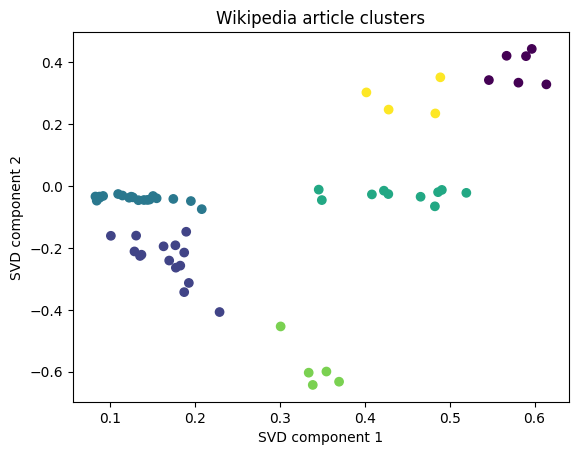

In [20]:
from scipy.sparse import csr_matrix
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.pipeline import make_pipeline

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("./datasets/wikipedia-vectors.csv", index_col=0)
articles = csr_matrix(df.values).T
title = df.columns


svd = TruncatedSVD()
kmeans = KMeans(n_clusters=6)

pipeline = make_pipeline(svd, kmeans)
pipeline.fit_transform(articles)

labels = pipeline.predict(articles)

df_clustered = pd.DataFrame({
    "title" : title,
    "labels" : labels
})

display(df_clustered.head())

# visualizing the clusters

svd_components = pipeline[0].transform(articles)
svd_component_1 = svd_components[:, 0]
svd_component_2 = svd_components[:, 1]

plt.scatter(svd_component_1, svd_component_2, c=labels)
plt.title("Wikipedia article clusters")
plt.xlabel("SVD component 1")
plt.ylabel("SVD component 2")
plt.show()
